In [4]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from matplotlib.backend_bases import MouseButton
from scipy.stats import pearsonr
from modules import *
from sklearn.svm import SVR
import pandas as pd
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules
from matplotlib.ticker import MultipleLocator


In [5]:
co_pre = pd.read_csv('pKRR-1.csv').iloc[:, 0].values
# co_pre = pd.read_csv('pGPR-1.csv').iloc[:, 0].values
re_pre = pd.read_csv('pSVR-2.csv').iloc[:, 0].values
co_pre=co_pre.reshape(-1, 1)
re_pre=re_pre.reshape(-1, 1)

forecast=np.array([co_pre[:,0], re_pre[:, 0]]).T
df=pd.DataFrame(forecast, columns=['Cohesive energy/eV', 'ρ$_0$×λ×10$^{-16}$/Ωm$^2$'])
df['index_label'] = None
df.iloc[0:135, df.columns.get_loc('index_label')] = 'Cu-base'
df.iloc[135:249, df.columns.get_loc('index_label')] = 'Co-base'
df.iloc[249:359, df.columns.get_loc('index_label')] = 'Ru-base'
df.iloc[359:472, df.columns.get_loc('index_label')] = 'Rh-base'
df.iloc[472:584, df.columns.get_loc('index_label')] = 'Ir-base'
df1=df.iloc[:,[0,2]]
# print(df1.head())
df2=df.iloc[:,1:3]
# print(df2.head())

df_cu=df[:135]
print(df_cu.describe())
df_co=df[135:249]
print(df_co.describe())
df_ru=df[249:359]
print(df_ru.describe())
df_rh=df[359:472]
print(df_rh.describe())
df_ir=df[472:584]
print(df_ir.describe())


       Cohesive energy/eV  ρ$_0$×λ×10$^{-16}$/Ωm$^2$
count          135.000000                 135.000000
mean             3.921634                   5.762533
std              0.930105                   0.852682
min              1.778190                   3.363821
25%              3.445889                   5.304659
50%              3.717862                   5.886131
75%              4.195791                   6.270074
max              7.507365                   7.826615
       Cohesive energy/eV  ρ$_0$×λ×10$^{-16}$/Ωm$^2$
count          114.000000                 114.000000
mean             4.556429                   4.981726
std              1.010727                   0.836639
min              1.943191                   3.427903
25%              3.995179                   4.569832
50%              4.488885                   4.875574
75%              4.963060                   5.426238
max              7.628153                   7.516240
       Cohesive energy/eV  ρ$_0$×λ×10$^{-16}$/

(584, 3)


C:\Users\Estelle\AppData\Local\Temp\ipykernel_4164\2146991227.py:23: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  ax=sns.boxplot(x=dx, y=dy1, data=df1, hue=dx,color="black", width=.15, zorder=10,


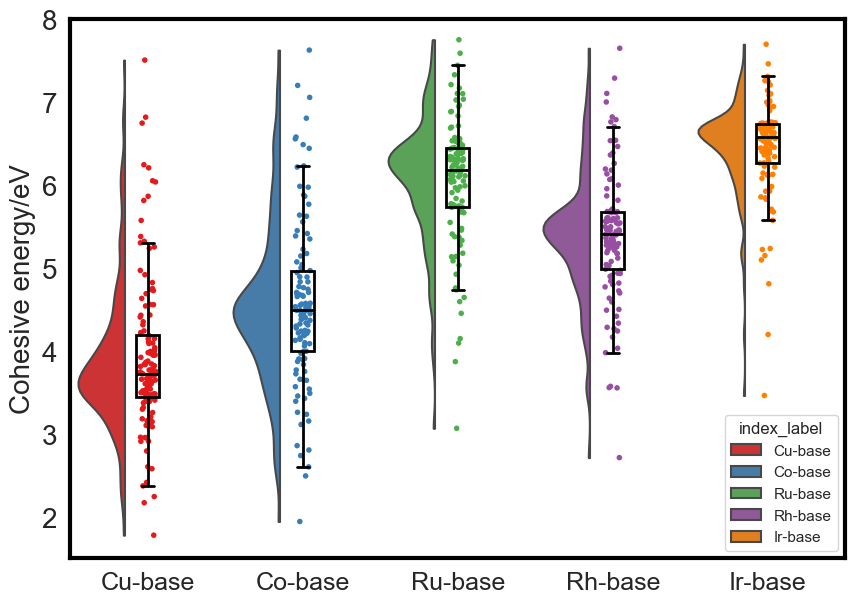

In [14]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
sns.set(style="darkgrid")
sns.set(style="whitegrid")
sns.set_style("white")

import matplotlib.collections as clt
import ptitprince as pt


dx="index_label" 
dy1="Cohesive energy/eV"
dy2="ρ$_0$×λ×10$^{-16}$/Ωm$^2$"
f, ax=plt.subplots(figsize=(10, 7))
pal="Set1"
print(df.shape)

ort = "v"
plt.ylim (1.5,8)
#绘制箱线图
ax=sns.boxplot(x=dx, y=dy1, data=df1, hue=dx,color="black", width=.15, zorder=10,
              showcaps=True, boxprops={'facecolor':'none',"zorder":10,'linewidth':2},
              showfliers=False, whiskerprops={'linewidth':2,"zorder":10}, 
              medianprops={'linewidth':2, 'color':'black'},
              capprops={'linewidth':2, 'color':'black'},
              saturation=1, orient=ort)
# 绘制横向小提琴图
ax=pt.half_violinplot(x=dx, y=dy1, data=df1, hue=dx,palette=pal, bw=.2, cut=0.,
                      scale="area", width=.6, inner=None, orient=ort)
# 绘制散点图
ax=sns.stripplot(x=dx, y=dy1, data=df1, hue=dx,palette=pal, edgecolor="black",
                 size=4, jitter=0.05, zorder=0, orient=ort)

# plt.title("Figure P5\n Tweaking the Colour of Your Raincloud")
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(3)

plt.ylabel("Cohesive energy/eV",fontsize=20) ## ρ$_0$×λ×10$^{-16}$/Ωm$^2$
# plt.axhline(y=5.1,linewidth=1, color='black',linestyle='--')
plt.xlabel(" ",fontsize=0)
plt.xticks(fontsize=18)
plt.yticks(fontsize=20)
# plt.show()
plt.savefig('forecast-co.png', bbox_inches='tight',dpi=300,transparent=True)
# plt.savefig('pareto.svg', bbox_inches='tight')


(584, 3)


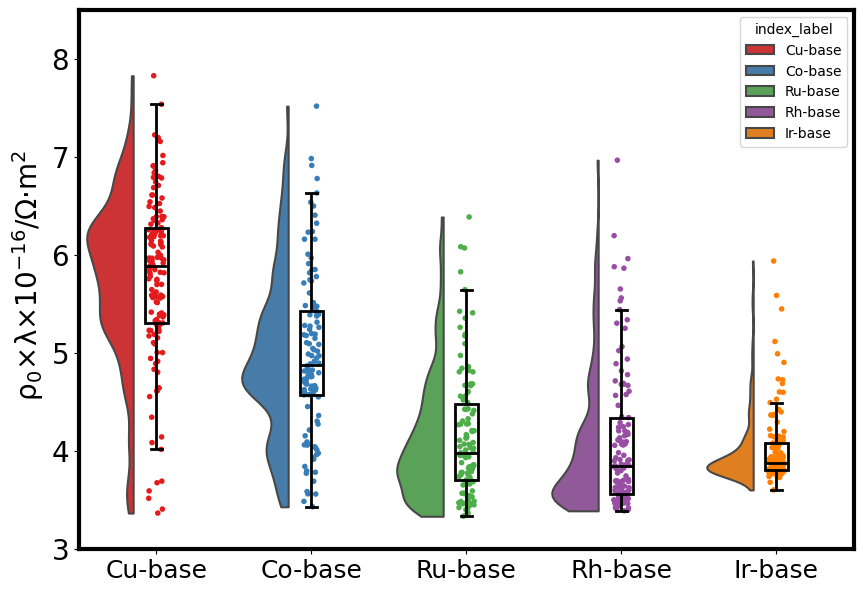

In [13]:
f, ax=plt.subplots(figsize=(10, 7))
pal="Set1"
print(df.shape)

ort = "v"
plt.ylim (3,8.5)
#绘制箱线图
ax=sns.boxplot(x=dx, y=dy2, data=df2, color="black", width=.15, zorder=10,
              showcaps=True, boxprops={'facecolor':'none',"zorder":10,'linewidth':2},
              showfliers=False, whiskerprops={'linewidth':2,"zorder":10}, 
              medianprops={'linewidth':2, 'color':'black'},
              capprops={'linewidth':2, 'color':'black'},
              saturation=1, orient=ort)
# 绘制横向小提琴图
ax=pt.half_violinplot(x=dx, y=dy2, data=df2, hue=dx,palette=pal, bw=.2, cut=0.,
                      scale="area", width=.6, inner=None, orient=ort)
# 绘制散点图
ax=sns.stripplot(x=dx, y=dy2, data=df2, hue=dx,palette=pal, edgecolor="red",
                 size=4, jitter=0.05, zorder=0, orient=ort,legend=False)

# plt.title("Figure P5\n Tweaking the Colour of Your Raincloud")
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(3)

plt.ylabel(" ρ$_0$×λ×10$^{-16}$/Ω·m$^2$",fontsize=20) ## ρ$_0$×λ×10$^{-16}$/Ωm$^2$
# plt.axhline(y=5.1,linewidth=1, color='black',linestyle='--')
plt.xlabel(" ",fontsize=0)
plt.xticks(fontsize=18)
plt.yticks(fontsize=20)
# plt.show()
plt.savefig('forecast-re.png', dpi=300,transparent=True,bbox_inches='tight')
# plt.savefig('pareto.svg', bbox_inches='tight')